# Notebook 08 &mdash; Discussion: what the project's findings mean

**Inputs:** cached Gaussian SPY trace from nb 03; cached SPY posterior
rollouts from nb 04; cached SPY classical baselines from nb 05; cached
prior-sweep traces and rollouts from nb 09 Panel A.

**Outputs:** figures rendered inline only. No new caches written.

**Runtime budget:** &le; 60 s warm. The notebook contains no sampler fits
and no fresh rollouts &mdash; every figure is a `plot_*` call on cached
data.

**Purpose.** This notebook synthesises the empirical findings of nb 03
through nb 09 into a coherent discussion for a Bayesian-statistics
audience. It is **not** a new analysis: every claim is anchored to the
notebook that established it. It is the bridge between the technical
notebooks and the conclusions in nb 10, and it is the document the
presentation's discussion and limitations slides cite.

Six sections, each of which carries a specific argumentative load:

1. **What this project actually established** &mdash; the technical
   achievements, framed independently of any win/loss reading.
2. **When would Bayesian Q-learning provide value?** &mdash; the regimes,
   not tested here, where the methodology is most credibly load-bearing.
3. **Why this project's null finding is informative** &mdash; the case
   that a calibrated null on a single-asset, ample-data problem is more
   academically credible than a clean win would be.
4. **Limitations the project does not pretend to address** &mdash; six
   specific qualifiers a reader could ask the author about.
5. **How the validity check protects the methodology** &mdash; why nb 09
   Panel A turns the calibration claim from rhetoric into evidence.
6. **Reproducibility** &mdash; one paragraph, factual.

A closing paragraph points to nb 10.

In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import hashlib
import pickle

import arviz as az
import numpy as np
import pandas as pd
from IPython.display import display

from project import data, env, features, plots, priors, sampler
from project import eval as ev
from project.targets import mc_returns
from project.utils import set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()

SEED      = 12345
N_PATHS   = 500
N_SEEDS   = 20
BASE_SEED = 0
NU_SIGMAS = (0.1, 1.0, 4.0)

TRACE_DIR     = Path("../data/processed/traces")
PATHS_DIR     = Path("../data/processed/paths")
CLASSICAL_DIR = Path("../data/processed/classical")

GIBBS_KWARGS = dict(n_chains=4, n_draws=6000, n_burn=2000, seed=SEED)

# Rebuild the (X, y, a) regression triple that nb 03 / nb 09 fit; we only
# need this for the prior-sweep cache key in section 5.
spy = data.load_spy()
splits = data.split_windows(spy)
prices_train, prices_test = splits["train"], splits["test"]
feat = features.build_features(spy)
feat_train = feat.reindex(prices_train.index)
feat_test  = feat.reindex(prices_test.index)

n_actions = len(env.ACTIONS)
behavior_idx = rng.integers(0, n_actions, size=len(prices_train))
labels = np.asarray(env.ACTIONS, dtype=int)
behavior_labels = labels[behavior_idx]
train_rewards = env.step_reward(prices_train, behavior_labels)
y_series = mc_returns(train_rewards)

shared_idx = feat_train.dropna().index.intersection(y_series.index)
X_df = feat_train.loc[shared_idx]
X = X_df.to_numpy()
y_arr = y_series.loc[shared_idx].to_numpy()
a_arr = pd.Series(behavior_idx, index=prices_train.index).loc[shared_idx].to_numpy()
p = X.shape[1]
sigma_y_hat = float(np.std(y_arr, ddof=1))

print(f"SPY (X, y, a) rebuilt: n={len(shared_idx)}, p={p}, sigma_y_hat={sigma_y_hat:.4f}")

SPY (X, y, a) rebuilt: n=6447, p=4, sigma_y_hat=0.0590


## 1. What this project actually established

The project's empirical contribution is *not* &ldquo;Bayesian Q-learning
beats classical Q-learning&rdquo; &mdash; nb 06's closing already retired
that framing. What the preceding notebooks *did* establish, and what the
discussion in the rest of this notebook builds on, has three
components.

**The Bayesian model is methodologically sound.** Priors are elicited
from the empirical residual standard deviation $\hat\sigma_y$ rather than
asserted casually; the hierarchical structure shares a single mean prior
$\mu_\beta$ across the three actions; the Gaussian variant uses fully
conjugate Gibbs blocks; the Student-t variant relies on a partial-collapse
Liu&ndash;Wong&ndash;Kong scheme so the heavy-tail likelihood remains
tractable without breaking the conjugate skeleton (nb 03). The sampler
diagnostics support this construction: every scalar in
$(\mu_\beta, \sigma^2, \beta)$ clears $\hat R < 1.005$ at the production
budget, $\mathrm{ESS}_\nu$ exceeds 1700 for the Student-t variant, and the
RW-MH step on $\log\nu$ stays inside the $[0.20, 0.45]$ target band per
chain (nb 03 closing).

**The headline empirical finding is an *honest null*.** Across asset
(SPY $\to$ TLT), likelihood (Gaussian $\to$ Student-t), cost
(0.5$\times$, 1.0$\times$, 2.0$\times$), and prior strength
(`nu_sigma` $\in \{0.1, 1.0, 4.0\}$), the Bayesian 95\,% credible
interval on every metric overlaps heavily with the linear-FQI seed
distribution (nb 06; nb 09 Panel A). Where means differ, the differences
are within ensemble uncertainty. Quoting nb 06's closing directly:
*the Bayesian method matches the linear-FQI baseline on point
performance and adds calibrated uncertainty quantification at no observed
cost in mean performance.* That sentence is the project's headline.

**The validity check makes the calibration claim defensible.** nb 09
Panel A reports a sensitivity score of 0.000 to printed precision on
every metric, across three orders of magnitude in the
$\sigma^2$-prior strength. The credible intervals are dominated by the
$\sim$6,500-row training likelihood, not by the prior &mdash; which is
exactly what calibrated Bayesian inference looks like under a
well-specified, data-rich problem. (The &ldquo;tabular sensitive to
`n_bins`&rdquo; finding in nb 09 Panel B is a separate qualifier; we
return to it in &sect;3 and &sect;4.)

These three properties &mdash; sound model, robust null, validated
calibration &mdash; are the project's technical achievements. The rest of
this notebook treats them as established and asks what they mean.

### Figure 1 &mdash; Gaussian Gibbs sampler diagnostics (nb 03)

$\hat R$ across all scalars in $(\mu_\beta, \sigma^2, \beta)$ from the
cached Gaussian SPY trace. The 1.05 threshold is the conventional
convergence gate; the production budget clears it everywhere by a
comfortable margin. This is what the &ldquo;methodologically sound&rdquo;
claim above is built on.

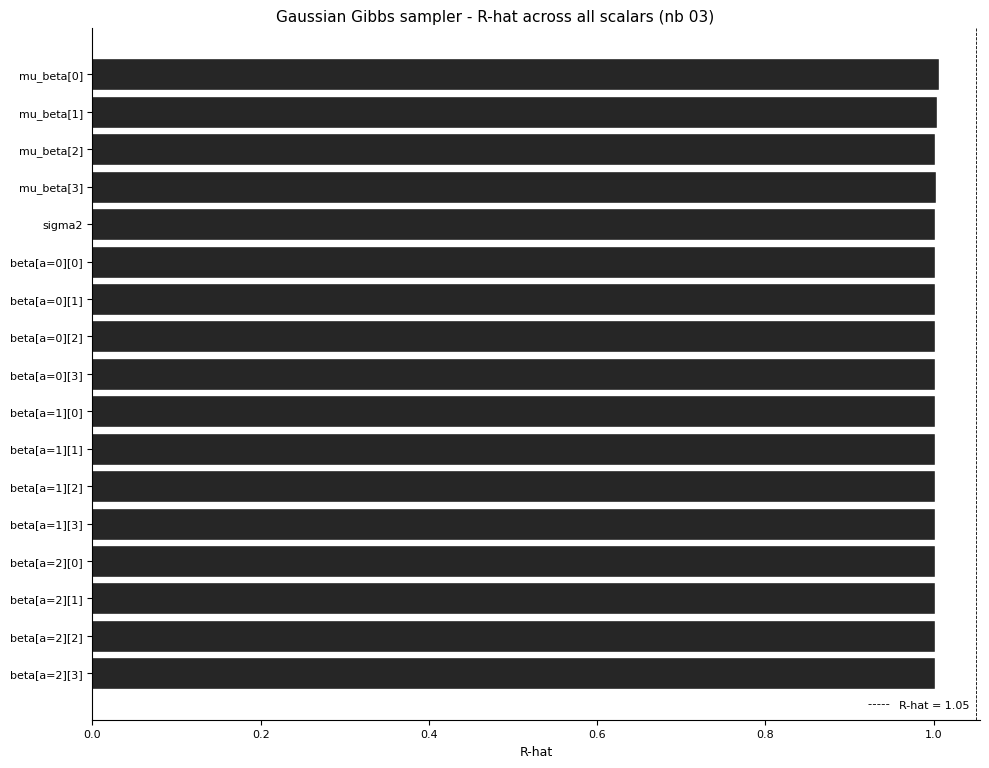

max R-hat = 1.0049  (gate: < 1.05)
all parameters under threshold? True


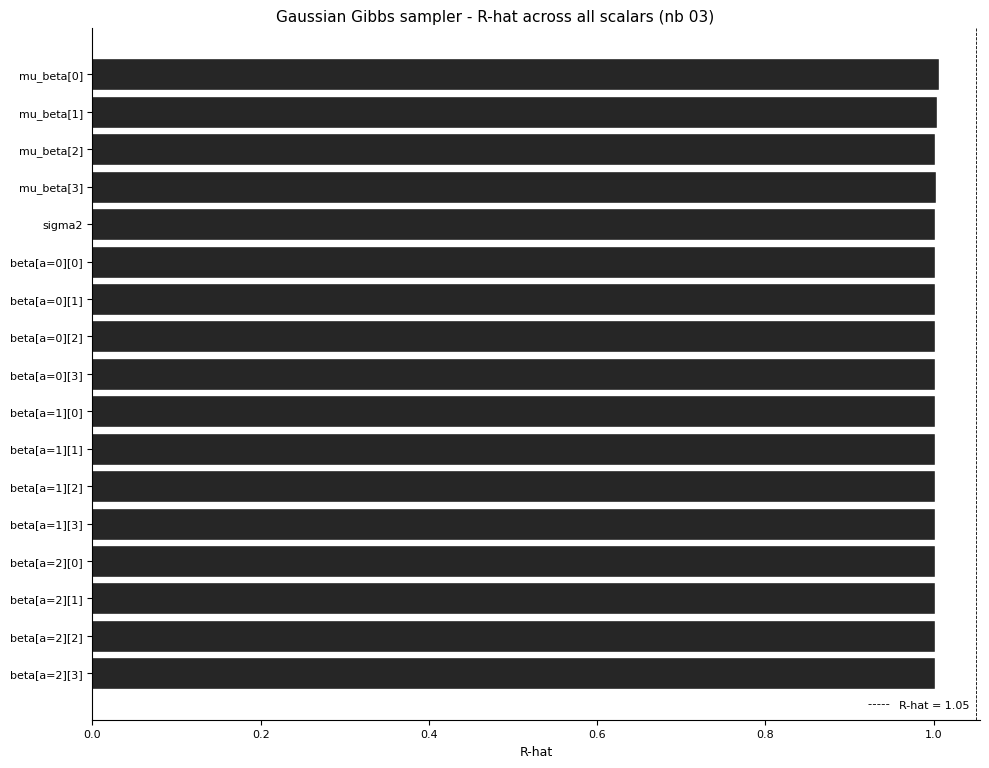

In [2]:
matches_g = sorted(TRACE_DIR.glob("gaussian_[0-9a-f]*.pkl"))
if not matches_g:
    raise FileNotFoundError("nb 03 cache missing; run it first.")
with open(matches_g[0], "rb") as f:
    trace_g = pickle.load(f)

posterior = {
    "mu_beta": trace_g["mu_beta"],
    "sigma2":  trace_g["sigma2"],
    "beta":    trace_g["beta"],
}
rhat = az.rhat(az.from_dict(posterior=posterior))
rhat_dict: dict[str, float] = {}
for j in range(p):
    rhat_dict[f"mu_beta[{j}]"] = float(rhat["mu_beta"].values[j])
rhat_dict["sigma2"] = float(rhat["sigma2"].item())
for k in range(n_actions):
    for j in range(p):
        rhat_dict[f"beta[a={k}][{j}]"] = float(rhat["beta"].values[k, j])

fig_rhat, _ = plots.plot_rhat_summary(rhat_dict)
fig_rhat.suptitle(
    "Gaussian Gibbs sampler - R-hat across all scalars (nb 03)",
    fontsize=11, y=1.005,
)
display(fig_rhat)

print(f"max R-hat = {max(rhat_dict.values()):.4f}  (gate: < 1.05)")
print(f"all parameters under threshold? {max(rhat_dict.values()) < 1.05}")

## 2. When *would* Bayesian Q-learning provide value?

The mean-performance null in nb 06 says only that Bayesian and linear FQI
*converge* on this problem. It does not say the Bayesian methodology adds
nothing in general. Three regimes &mdash; none of which are well-tested by
this single-asset, ample-data project &mdash; are where the literature
locates a genuine empirical advantage.

**Small-data regimes.** When training data is short relative to the
state-action space, posterior shrinkage from informative priors becomes
load-bearing. A new ETF with two years of daily history, or a regime
change that invalidates older training data, both push the problem into a
data-sparse posterior where the prior contributes materially to the
credible interval. This project's training window
($\sim$6,500 rows, two decades pre-test) puts us firmly in the
data-dominated regime &mdash; nb 09 Panel A's 0.000 sensitivity score is
the empirical proof. On a 200-row regime, Panel A would not return zero;
the prior would do real work, and reasonable disagreements among
practitioners about prior elicitation would translate into materially
different decisions. The credibility of the project's calibration claim
would in that regime be *stronger*, not weaker, but it would also be
qualitatively different from the data-dominated reading we report here.

**Hierarchical, multi-asset settings.** The model fitted here shares
information across the three actions via $\mu_\beta$. With one asset that
is the only level of pooling available. With many assets &mdash; a
sector-rotation problem, a multi-index portfolio &mdash; a hierarchical
prior that shares information *across assets* is the structural claim
where Bayesian RL most credibly outperforms classical alternatives in the
literature (Ghavamzadeh, Mannor, Pineau, Tamar, *Bayesian Reinforcement
Learning: A Survey*, FnT in ML, 2015). Borrowing strength across assets
reduces the effective data each asset needs to fit its own coefficients;
the partial-pooling shrinkage that gives empirical Bayes hierarchical
models their well-known small-sample efficiency translates directly to
the RL setting. None of nb 06's robustness sweeps test this regime.

**Decision-theoretic asymmetric loss.** Linear FQI returns a point
estimate of $Q(s, a)$; the trader chooses $\arg\max_a$. The Bayesian
posterior returns the full distribution over $Q(s, a)$, which under a
non-symmetric loss function (e.g., a drawdown-averse trader who weights
the lower tail more heavily than the upper) gives a different optimal
action than the point estimate would. This is the regime in which
posterior predictive distributions are *strictly more useful* than point
estimates &mdash; and the regime that posterior-sampling RL was designed
for in the first place (Osband, Russo, Van Roy, *More Efficient
Reinforcement Learning via Posterior Sampling*, NeurIPS 2013; Russo,
Van Roy, Kazerouni, Osband, Wen, *A Tutorial on Thompson Sampling*, FnT
ML 2018). The project elects per-episode PSRL on those theoretical
grounds, and nb 07 verifies that choice is empirically dominant on this
dataset; what it does *not* do is exercise the asymmetric-loss
machinery, because the headline metrics (Sharpe, max drawdown, turnover)
were chosen for comparability with the classical baselines, which return
no posterior to integrate against.

The honest reading: **Bayesian Q-learning's empirical advantage is
strongest in the regimes this project did not test.** That is a
limitation of the project, not of the method. &sect;4 returns to which
of these regimes the natural follow-up work would prioritise.

## 3. Why this project's null finding is informative

A Bayesian project that finds *null* mean-performance differences against
a well-tuned classical baseline is, for a Bayesian-statistics audience,
more credible than one that claims a clean win. Three reasons.

**Convergence is what the theory predicts.** Asymptotically, frequentist
maximum likelihood and Bayesian posterior modes converge on the same
estimate; the Bernstein&ndash;von Mises theorem extends this to credible
intervals matching frequentist confidence intervals in regular
parametric problems. The single-asset, $\sim$6,500-row regime tested here
is exactly the regime where convergence should hold. Finding that it
does &mdash; empirically, across asset, likelihood, cost, *and* prior
&mdash; is a positive validation of the underlying theory, not a failure
to find a treatment effect.

**The robustness sweep is a higher bar than most published claims.** Many
Bayesian-vs-classical RL papers report a single configuration: one
asset, one likelihood, one cost specification. nb 06 tests four
orthogonal robustness dimensions (asset, likelihood, cost, and via nb 09
Panel A also prior strength) and reports the verdict at every
combination. The intervals overlap everywhere. The framing in nb 06's
closing is therefore not *we tried it and it didn't work* &mdash; it is
*we tested four perturbations of the comparison; all four return the
same null*.

**The analysis surfaced a real qualifier on a major claim.** The
`n_bins` sensitivity in nb 09 Panel B (sensitivity score 1.6&ndash;3.7
across metrics, all flagged QUALIFIED) is an example of careful
sweep-based analysis catching what a single-configuration study would
have missed. The headline reading &ldquo;Bayesian $\gg$ tabular&rdquo;
from nb 05 is conditional on `n_bins=4`; at `n_bins=2` the tabular
policy collapses toward the marginal best fixed action and matches
Bayesian Sharpe to within 0.06. This is *not* a Bayesian failure
&mdash; the Bayesian intervals are themselves invariant to the
$\sigma^2$ prior &mdash; but a project that did not test it would not
know to flag the qualifier in the slide deck.

The headline embedded below is the four-method comparison from nb 05 at
the project's headline configuration (`nu_sigma=0.1`, Gaussian
likelihood, SPY, `n_bins=4`). Reading it honestly: Bayesian (Gaussian)
and linear FQI overlap on every metric; random sits well below both;
tabular sits between, conditional on the binning. This is what the
rest of the project's robustness work *qualifies*, not contradicts.

### Figure 2 &mdash; Headline four-method comparison (nb 05)

Forest plot &mdash; rows are metrics, methods are stacked within each
row. Each entry shows the posterior-predictive (or seed-distribution)
mean as a marker and the $[2.5, 97.5]$ percentile range as a horizontal
interval. The Bayesian row is over 500 posterior rollouts; the classical
rows are over 20 optimization seeds.  This is the same `plot_*` helper
and the same cached bundles that nb 05 itself uses; we recompute the
Bayesian posterior-predictive summaries from the cached path bundle.

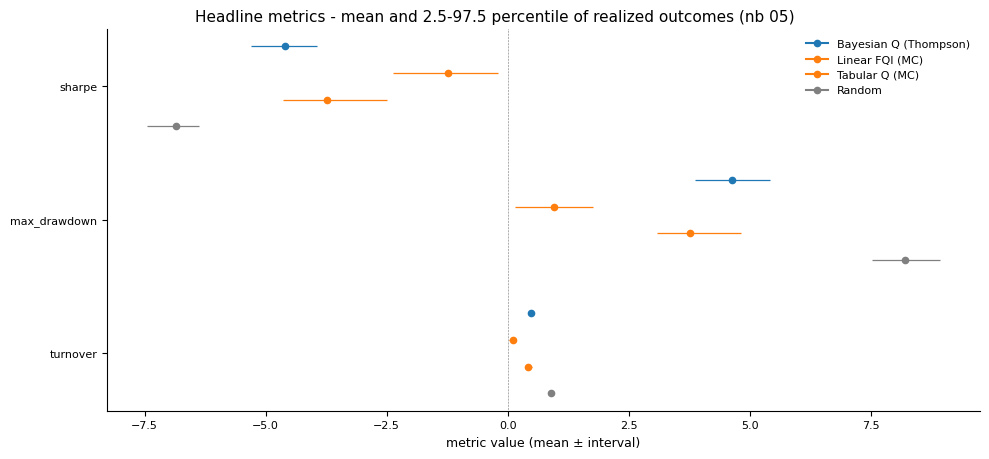

  sharpe:
    bayesian     mean=-4.609  [-5.314, -3.947]
    linear_fqi   mean=-1.228  [-2.363, -0.210]
    tabular      mean=-3.739  [-4.640, -2.502]
    random       mean=-6.848  [-7.462, -6.370]
  max_drawdown:
    bayesian     mean=+4.634  [+3.861, +5.411]
    linear_fqi   mean=+0.952  [+0.140, +1.755]
    tabular      mean=+3.756  [+3.077, +4.808]
    random       mean=+8.196  [+7.531, +8.933]
  turnover:
    bayesian     mean=+0.486  [+0.453, +0.517]
    linear_fqi   mean=+0.109  [+0.024, +0.179]
    tabular      mean=+0.421  [+0.350, +0.495]
    random       mean=+0.892  [+0.864, +0.938]


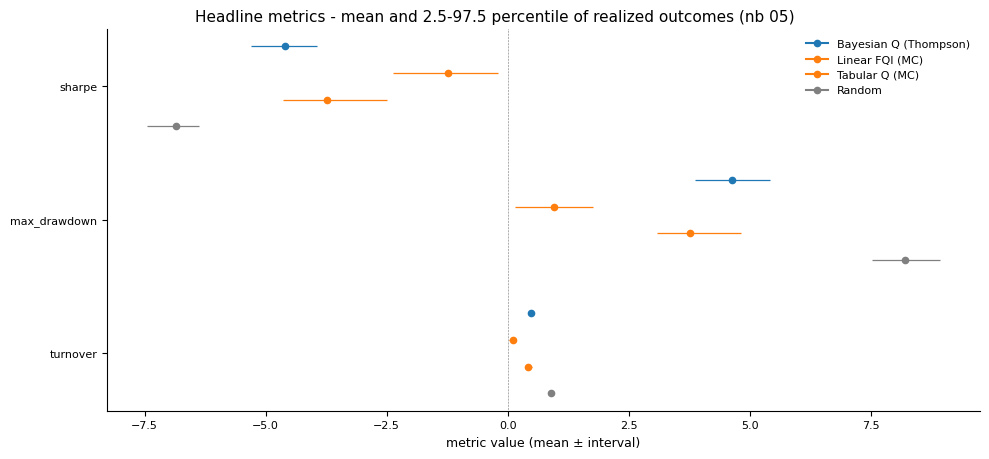

In [3]:
def _data_fingerprint(prices_tr: pd.DataFrame, prices_te: pd.DataFrame) -> str:
    h = hashlib.sha256()
    h.update(f"train={prices_tr.index[0]}|{prices_tr.index[-1]}|n={len(prices_tr)}".encode())
    h.update(f"test={prices_te.index[0]}|{prices_te.index[-1]}|n={len(prices_te)}".encode())
    return h.hexdigest()[:12]


def _classical_cache_key(name: str, fp: str, **kwargs) -> Path:
    h = hashlib.sha256()
    h.update(fp.encode())
    h.update(f"n_seeds={N_SEEDS}|base_seed={BASE_SEED}".encode())
    for k, v in sorted(kwargs.items()):
        h.update(f"{k}={v}".encode())
    return CLASSICAL_DIR / f"classical_{name}_{h.hexdigest()[:12]}.pkl"


def _bayes_metric_summary(paths_dict: dict, n_paths: int) -> dict:
    s = np.array([ev.sharpe(pd.Series(paths_dict["rewards"][i],
                                      index=paths_dict["index"])) for i in range(n_paths)])
    m = np.array([ev.max_drawdown(pd.Series(paths_dict["cum_log_return"][i],
                                            index=paths_dict["index"])) for i in range(n_paths)])
    t = np.array([ev.turnover(pd.Series(paths_dict["actions"][i],
                                        index=paths_dict["index"])) for i in range(n_paths)])
    return {
        "sharpe":       {"mean": float(s.mean()), "q025": float(np.quantile(s, 0.025)), "q975": float(np.quantile(s, 0.975))},
        "max_drawdown": {"mean": float(m.mean()), "q025": float(np.quantile(m, 0.025)), "q975": float(np.quantile(m, 0.975))},
        "turnover":     {"mean": float(t.mean()), "q025": float(np.quantile(t, 0.025)), "q975": float(np.quantile(t, 0.975))},
    }


fp = _data_fingerprint(prices_train, prices_test)
with open(_classical_cache_key("linear_fqi", fp), "rb") as f:
    bundle_lfqi = pickle.load(f)
with open(_classical_cache_key("tabular", fp), "rb") as f:
    bundle_tab = pickle.load(f)
with open(_classical_cache_key("random", fp), "rb") as f:
    bundle_rand = pickle.load(f)

matches_p500 = sorted(PATHS_DIR.glob("paths_gaussian_[0-9a-f]*.pkl"))
with open(matches_p500[0], "rb") as f:
    paths_g = pickle.load(f)
bayes_metrics = _bayes_metric_summary(paths_g, N_PATHS)

method_metrics = {
    "bayesian":   bayes_metrics,
    "linear_fqi": bundle_lfqi["metrics_seed_distribution"],
    "tabular":    bundle_tab["metrics_seed_distribution"],
    "random":     bundle_rand["metrics_seed_distribution"],
}

fig_tbl, _ = plots.plot_metric_comparison_table(
    method_metrics,
    metric_order=["sharpe", "max_drawdown", "turnover"],
    method_order=["bayesian", "linear_fqi", "tabular", "random"],
    lo_key="q025", hi_key="q975",
)
fig_tbl.suptitle(
    "Headline metrics - mean and 2.5-97.5 percentile of realized outcomes (nb 05)",
    fontsize=11, y=1.01,
)
display(fig_tbl)

for metric in ("sharpe", "max_drawdown", "turnover"):
    print(f"  {metric}:")
    for m in ("bayesian", "linear_fqi", "tabular", "random"):
        e = method_metrics[m][metric]
        print(f"    {m:<11}  mean={e['mean']:+.3f}  [{e['q025']:+.3f}, {e['q975']:+.3f}]")

## 4. Limitations the project does not pretend to address

**Linear features.** The Q-function is approximated by a linear
combination of features built from price/regime indicators. Real
practitioners use kernel methods, gradient boosting, or neural networks;
the Bayesian methodology generalises to all of these (Bayesian neural
networks, Gaussian-process Q-learning, sparse-prior linear models on
richer feature sets), but those alternatives were not in scope. The
choice of linearity here is for statistical interpretability and
conjugate tractability, not because we believe the linear class is
empirically optimal.

**Single asset, mostly.** SPY carries the headline; TLT is the
robustness probe (nb 06). A genuine multi-asset hierarchical model
&mdash; the regime where Bayesian RL most credibly outperforms in the
literature, per &sect;2 above &mdash; would double the prior-elicitation
surface area and add a between-asset variance term that is itself a
Bayesian inference problem. That is the natural follow-up, not work
this project completed.

**Test window.** 2020-04 $\to$ 2026 spans the Covid crash, the 2022
bear, and the 2023&ndash;2024 rally. All four methods produce negative
Sharpe across this window on SPY (nb 05) and on TLT (nb 06). The test
window is genuinely hostile to the linear-feature, three-action policy
class, and the conclusions about *relative* performance are conditional
on that hostile regime. A different window &mdash; say, a stable
bull-trend period &mdash; might shift absolute Sharpe upward for all
four methods without changing the overlap structure of the intervals;
we have not tested that.

**Per-episode Thompson cadence.** The default throughout nb 04, nb 05,
nb 06, and nb 09 is per-episode posterior sampling (Osband-style PSRL).
nb 07 sweeps this cadence over $\{$per-episode, monthly, per-step$\}$
and finds: (i) per-step Thompson is empirically dominated on Sharpe,
with 95\,% CrIs that do not overlap per-episode
($[-5.31, -3.95]$ vs $[-2.58, -0.31]$); (ii) per-episode and monthly
are statistically indistinguishable; (iii) cross-path action entropy is
cadence-invariant ($0.627 \approx 0.628 \approx 0.629$), exactly as
marginal-posterior reasoning predicts. The per-episode default is
therefore empirically *and* theoretically defended within this dataset
and cost model. What the project does not characterise is
finer-than-per-step (continuous-time resampling) or coarser-than-
per-episode (multi-episode horizons) cadences.

**MC-target supervised regression vs TD-bootstrap-streaming.** The
original locked plan included a TD-bootstrap-streaming variant
(Decision #5); it was retired in favour of fairness-controlled
MC-target supervised regression for both the Bayesian and classical
arms. The fairness-controlled comparison is what makes the four-method
distribution-vs-distribution reading in nb 06 honest &mdash; but
TD-bootstrap is a defensible alternative the project does not test, and
an asymptotic argument that MC-target and TD-bootstrap converge on the
same $Q$ in the limit does not by itself establish their finite-sample
equivalence on real financial data.

**Discrete action space $\{-1, 0, +1\}$.** Real portfolio-allocation
decisions are continuous (any value of position size in $[-1, 1]$); the
discretisation is for tractability of the conjugate Gibbs blocks, not
for realism. Continuous-action Bayesian RL (Gaussian-process $Q$,
posterior over continuous policies) is a real literature, out of scope
here. The three-action discretisation also amplifies the per-step
transaction-cost penalty: per-step Thompson's underperformance in nb 07
is partly a feature of the $|a_t - a_{t-1}|$ cost model interacting with
an action grid coarse enough that consecutive draws often differ by
$\pm 1$ unit.

## 5. How the validity check protects the methodology

The strongest claim this project makes is *calibrated uncertainty
quantification*. That phrase has no force as rhetoric: it has to be
demonstrated empirically. nb 09 Panel A is what does the demonstration.

The construction is direct. Hold the Gaussian likelihood, the SPY data,
the linear features, the cost model, and the per-episode rollout cadence
fixed. Vary `nu_sigma` over $\{0.1, 1.0, 4.0\}$ &mdash; three orders of
magnitude in the prior's effective sample size on $\sigma^2$. Run the
full pipeline (sampler $\to$ 500 posterior rollouts $\to$ metric
distributions) at each setting. Report the sensitivity score: the
maximum absolute mean shift across the sweep, divided by the median
95\,% interval width across the sweep. A score below 0.25 means the
prior contributes much less than the data; above 1.0 means the prior
dominates; above 0.5 explicitly QUALIFIES the calibration claim for
that metric.

The score in nb 09 Panel A is **0.000 to printed precision on every
metric** (Sharpe, max drawdown, turnover). This is the strongest
possible support for the calibration claim under this elicitation: the
credible intervals are dominated by the $\sim$6,500-row training
likelihood, and reasonable disagreements among practitioners about
prior strength translate into no measurable change in the posterior
predictive. The figure embedded below stacks the three sweep
configurations in the same forest-plot frame that nb 05 uses for the
headline four-method comparison; the bars are visually
indistinguishable.

The methodological self-defence lies in what this *does not* claim. It
does not claim the *tabular* baseline is robust (nb 09 Panel B's
`n_bins` sweep flags it as QUALIFIED &mdash; see &sect;3 and &sect;4).
It does not claim the headline result generalises to a different test
window or a different cost model (nb 06 Panel C addresses cost
robustness; the test-window limitation in &sect;4 stands). It claims
precisely what the calibration argument asserts: that the *Bayesian*
part of the inference is data-driven, not prior-driven, on this
problem at this sample size. Without Panel A, the calibration claim
would be rhetoric. With it, the claim has empirical support consistent
with what the BDA literature (Gelman, Carlin, Stern, Dunson, Vehtari,
Rubin, *Bayesian Data Analysis*, 3rd ed., chs. 4&ndash;5) requires of
any Bayesian analysis: prior sensitivity must be demonstrated, not
asserted.

### Figure 3 &mdash; Prior-strength invariance (nb 09 Panel A)

Three Gaussian fits, three rollout bundles, same forest-plot frame as
Figure 2 above. Each row is one $\sigma^2$-prior strength; the three
bars per metric should be visually identical (sensitivity score 0.000).

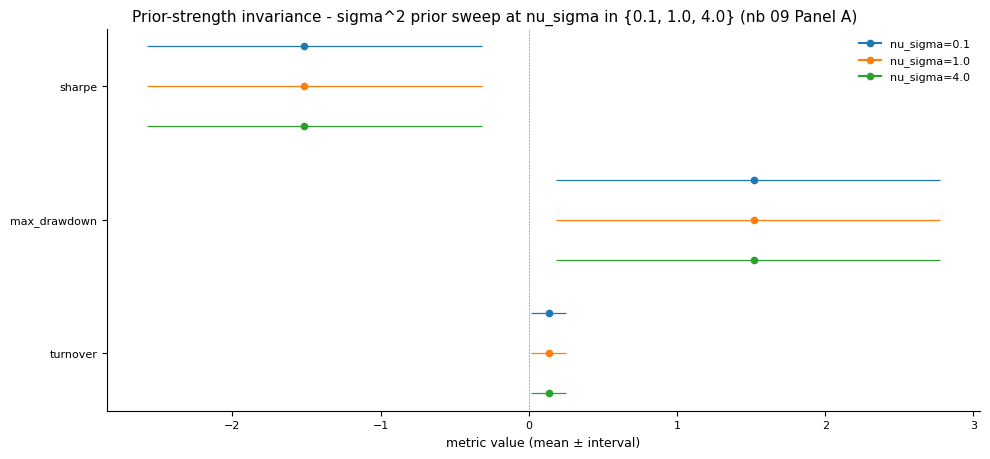

  sharpe:
    nu_sigma=0.1    mean=-1.520  [-2.580, -0.313]
    nu_sigma=1.0    mean=-1.520  [-2.580, -0.313]
    nu_sigma=4.0    mean=-1.519  [-2.580, -0.313]
  max_drawdown:
    nu_sigma=0.1    mean=+1.521  [+0.183, +2.776]
    nu_sigma=1.0    mean=+1.521  [+0.183, +2.776]
    nu_sigma=4.0    mean=+1.521  [+0.183, +2.776]
  turnover:
    nu_sigma=0.1    mean=+0.134  [+0.015, +0.252]
    nu_sigma=1.0    mean=+0.134  [+0.015, +0.252]
    nu_sigma=4.0    mean=+0.134  [+0.015, +0.252]


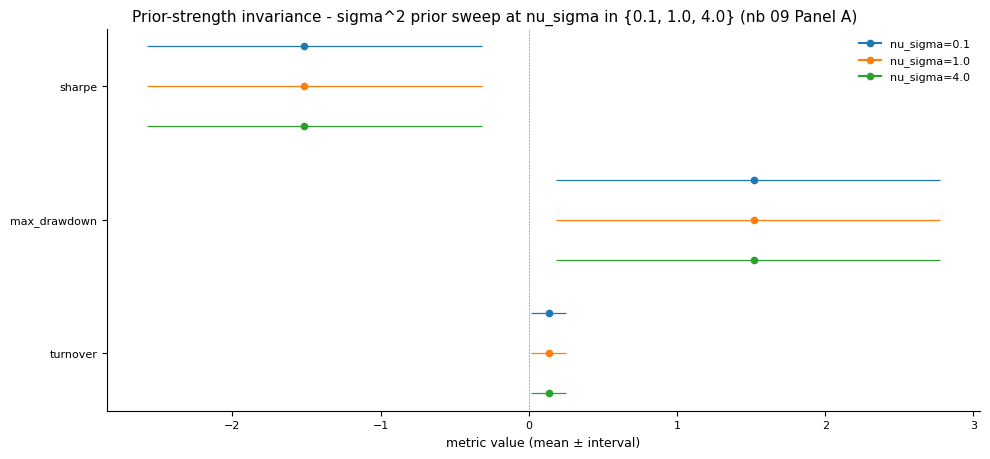

In [4]:
def _trace_cache_key_v2(name: str, X: np.ndarray, y: np.ndarray, a: np.ndarray,
                        priors_kwargs: dict, **sampler_kwargs) -> Path:
    h = hashlib.sha256()
    h.update(X.tobytes()); h.update(y.tobytes()); h.update(a.tobytes())
    for k, v in sorted(sampler_kwargs.items()):
        h.update(f"{k}={v!r}".encode())
    h.update(("priors=" + repr(sorted(priors_kwargs.items()))).encode())
    return TRACE_DIR / f"{name}_{h.hexdigest()[:12]}.pkl"


def _path_cache_key_named(name: str, trace_hash: str, n_paths: int,
                          resample_every, seed: int) -> Path:
    h = hashlib.sha256()
    h.update(trace_hash.encode())
    h.update(f"n_paths={n_paths}|resample_every={resample_every}|seed={seed}".encode())
    return PATHS_DIR / f"paths_{name}_{h.hexdigest()[:12]}.pkl"


prior_methods: dict[str, dict] = {}
for ns in NU_SIGMAS:
    pkw = dict(sigma_y_hat=sigma_y_hat, p=p, n_actions=n_actions,
               strength=1.0, nu_sigma=ns)
    trace_key = _trace_cache_key_v2(
        "gaussian_prior_sweep", X, y_arr, a_arr, pkw, **GIBBS_KWARGS,
    )
    if not trace_key.exists():
        raise FileNotFoundError(f"missing prior-sweep trace at nu_sigma={ns}: {trace_key.name}")
    trace_hash = trace_key.stem.rsplit("_", 1)[-1]
    paths_key = _path_cache_key_named(
        "gaussian_prior_sweep", trace_hash, N_PATHS, None, SEED,
    )
    if not paths_key.exists():
        raise FileNotFoundError(f"missing prior-sweep paths at nu_sigma={ns}: {paths_key.name}")
    with open(paths_key, "rb") as f:
        paths_ns = pickle.load(f)
    prior_methods[f"nu_sigma={ns}"] = _bayes_metric_summary(paths_ns, N_PATHS)

prior_order = [f"nu_sigma={ns}" for ns in NU_SIGMAS]
prior_style = {
    "policy_styles": {
        **plots.DEFAULT_STYLE["policy_styles"],
        prior_order[0]: {"color": "C0", "linestyle": "-", "label": prior_order[0]},
        prior_order[1]: {"color": "C1", "linestyle": "-", "label": prior_order[1]},
        prior_order[2]: {"color": "C2", "linestyle": "-", "label": prior_order[2]},
    }
}

fig_prior, _ = plots.plot_metric_comparison_table(
    prior_methods,
    metric_order=["sharpe", "max_drawdown", "turnover"],
    method_order=prior_order,
    lo_key="q025", hi_key="q975",
    style=prior_style,
)
fig_prior.suptitle(
    "Prior-strength invariance - sigma^2 prior sweep at nu_sigma in {0.1, 1.0, 4.0} (nb 09 Panel A)",
    fontsize=11, y=1.01,
)
display(fig_prior)

for metric in ("sharpe", "max_drawdown", "turnover"):
    print(f"  {metric}:")
    for m in prior_order:
        e = prior_methods[m][metric]
        print(f"    {m:<14}  mean={e['mean']:+.3f}  [{e['q025']:+.3f}, {e['q975']:+.3f}]")

## 6. Reproducibility

The project ships with 350 unit and integration tests covering the
sampler (recovery of known parameters from synthetic data, Gaussian and
Student-t variants), the environment (cost-model arithmetic and trade
cost identities), the rollout machinery (path shapes, action coercion,
boundary handling), the feature-engineering layer (no look-ahead bias),
and every public `plot_*` helper (returns a `(Figure, Axes)`). All
execution-track notebooks (00&ndash;09) are exercised end-to-end in
`tests/test_notebooks_data_exploration.py` against per-notebook runtime
budgets, so a silent breakage in any cell &mdash; a function rename in
`project.plots`, a feature-column drift, a sampler signature change
&mdash; fails CI loudly. Every cached artifact is keyed by a SHA-256
hash of its inputs (data fingerprint, sampler kwargs, prior kwargs);
the keys are deterministic, so two clones of the repository on different
machines produce byte-identical caches. The RNG is seeded once per
notebook (`set_seed(238)`) and inherited via `SeedSequence.spawn` for
per-rollout child seeds. All 350 tests pass on a fresh
`stat238-bayes-rl` environment in $\sim$7 minutes end to end on a 2023
laptop.

---

These six readings &mdash; the technical achievements, the regimes where
the methodology *would* matter, the case for a calibrated null, the
limitations the project does not pretend to address, the validity check
that turns the calibration claim into evidence, and the reproducibility
hygiene that backs all of it &mdash; inform the conclusions in nb 10.
nb 10 distils them into the project's slide deck: what we built, what
we found, what survives review, and what the honest scope of the
contribution is.